## How to Run

1. Download parquet files from OneDrive:

2. Place them in the same directory as the notebook

3. Run the pipeline

Source table row counts:
             table_name  row_count
0              patients      71518
1            encounters     101766
2              clinical     101766
3  medications_outcomes     101766
Random Forest AUC: 0.69
Logistic Regression AUC: 0.674

Top Features:
                          feature  rf_importance  log_coef
3          Prior Inpatient Visits       0.130453  0.303229
42             Discharged to Home       0.036334 -0.137144
6           Number of Medications       0.034481  0.044091
44                        Expired       0.033563 -3.849713
4                  Lab Procedures       0.030687 -0.002371
0                  Length of Stay       0.030492 -0.022180
2                Emergency Visits       0.028833  0.034882
7             Number of Diagnoses       0.024547  0.024460
55  Transferred to Rehab Facility       0.024461  1.116537
1               Outpatient Visits       0.014470 -0.001743


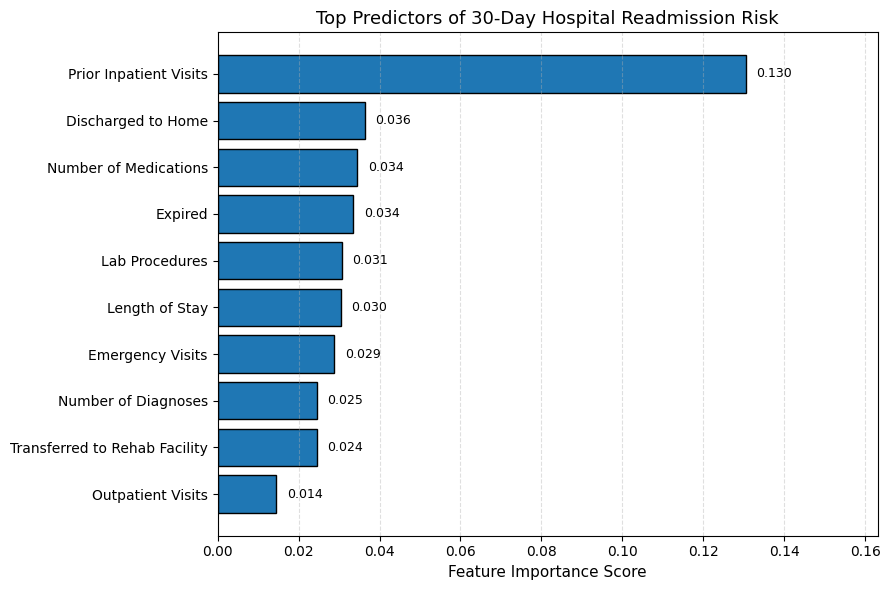

In [ ]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import logging

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Configure logging
# This creates a log file so pipeline steps and errors are recorded.
logging.basicConfig(
    filename="pipeline.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logging.info("Pipeline started.")

# Connect to DuckDB and load data
try:
    # Connect to a local DuckDB database file.
    con = duckdb.connect("hospital_readmission.duckdb")
    logging.info("Connected to DuckDB successfully.")

    # Drop existing tables so the pipeline can be rerun cleanly.
    con.execute("DROP TABLE IF EXISTS patients")
    con.execute("DROP TABLE IF EXISTS encounters")
    con.execute("DROP TABLE IF EXISTS clinical")
    con.execute("DROP TABLE IF EXISTS medications_outcomes")

    # Load each parquet file into DuckDB as its own relational table.
    con.execute("CREATE TABLE patients AS SELECT * FROM read_parquet('patients.parquet')")
    con.execute("CREATE TABLE encounters AS SELECT * FROM read_parquet('encounters.parquet')")
    con.execute("CREATE TABLE clinical AS SELECT * FROM read_parquet('clinical.parquet')")
    con.execute("CREATE TABLE medications_outcomes AS SELECT * FROM read_parquet('medications_outcomes.parquet')")

    logging.info("Parquet files loaded into DuckDB successfully.")

except Exception as e:
    logging.error(f"Error connecting to DuckDB or loading parquet files: {e}")
    raise

# Validate source tables
try:
    # Check that all tables loaded and contain rows.
    row_counts = con.sql("""
        SELECT 'patients' AS table_name, COUNT(*) AS row_count FROM patients
        UNION ALL
        SELECT 'encounters', COUNT(*) FROM encounters
        UNION ALL
        SELECT 'clinical', COUNT(*) FROM clinical
        UNION ALL
        SELECT 'medications_outcomes', COUNT(*) FROM medications_outcomes
    """).df()

    print("Source table row counts:")
    print(row_counts)

    logging.info("Source table validation completed successfully.")

except Exception as e:
    logging.error(f"Error validating source tables: {e}")
    raise

# Join the four tables
try:
    # Join all relational tables into one analytic dataset.
    # This combines patient, encounter, clinical, and medication/outcome data.
    model_df = con.sql("""
    SELECT
        e.encounter_id,
        e.patient_nbr,
        p.race,
        p.gender,
        p.age,
        p.weight,
        e.admission_type_id,
        e.discharge_disposition_id,
        e.admission_source_id,
        e.time_in_hospital,
        e.payer_code,
        e.medical_specialty,
        e.number_outpatient,
        e.number_emergency,
        e.number_inpatient,
        c.num_lab_procedures,
        c.num_procedures,
        c.num_medications,
        c.number_diagnoses,
        c.diag_1,
        c.diag_2,
        c.diag_3,
        c.max_glu_serum,
        c.A1Cresult,
        m.metformin,
        m.insulin,
        m.change,
        m.diabetesMed,
        m.readmitted
    FROM encounters e
    JOIN patients p USING (patient_nbr)
    JOIN clinical c USING (encounter_id)
    JOIN medications_outcomes m USING (encounter_id)
    """).df()

    logging.info("Successfully joined the four tables into model_df.")

except Exception as e:
    logging.error(f"Error joining tables: {e}")
    raise

# Clean and prepare data
try:
    # Replace placeholder strings with true missing values.
    for col in model_df.columns:
        if model_df[col].dtype == object:
            model_df[col] = model_df[col].replace({
                "?": np.nan,
                "NULL": np.nan,
                "Not Available": np.nan,
                "Not Mapped": np.nan,
                "Unknown/Invalid": np.nan
            })

    # Cap very large outpatient counts to reduce extreme skew.
    # This prevents a few unusually large values from dominating the model.
    model_df["number_outpatient"] = model_df["number_outpatient"].clip(upper=10)

    # These ID variables are coded categories, not true numeric quantities.
    # Convert them to strings so they are treated as categorical features.
    model_df["admission_type_id"] = model_df["admission_type_id"].astype(str)
    model_df["discharge_disposition_id"] = model_df["discharge_disposition_id"].astype(str)
    model_df["admission_source_id"] = model_df["admission_source_id"].astype(str)

    # Create the binary target:
    # 1 = readmitted within 30 days
    # 0 = not readmitted within 30 days
    model_df["readmit_30d"] = (model_df["readmitted"] == "<30").astype(int)

    logging.info("Data cleaning and target creation completed successfully.")

except Exception as e:
    logging.error(f"Error during data cleaning and preparation: {e}")
    raise

# Select features and target
try:
    # Remove identifiers and the original outcome columns from predictors.
    X = model_df.drop(columns=["readmitted", "readmit_30d", "encounter_id", "patient_nbr"])
    y = model_df["readmit_30d"]

    # Separate categorical and numeric feature columns for preprocessing.
    categorical_cols = X.select_dtypes(include="object").columns.tolist()
    numeric_cols = [col for col in X.columns if col not in categorical_cols]

    logging.info("Feature matrix and target vector created successfully.")

except Exception as e:
    logging.error(f"Error preparing features and target: {e}")
    raise

# Build preprocessing pipeline
try:
    # Numeric features:
    # - impute missing values with the median
    # - standardize values for logistic regression stability
    #
    # Categorical features:
    # - impute missing values with the most common category
    # - one-hot encode for use in the models
    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols)
    ])

    logging.info("Preprocessing pipeline created successfully.")

except Exception as e:
    logging.error(f"Error creating preprocessing pipeline: {e}")
    raise

# Define models
try:
    # Random Forest:
    # Used for stronger predictive performance and feature importance.
    rf_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            min_samples_leaf=10,
            class_weight="balanced_subsample",
            random_state=42
        ))
    ])

    # Logistic Regression:
    # Used for interpretability because coefficient signs show direction of association.
    log_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=3000))
    ])

    logging.info("Models created successfully.")

except Exception as e:
    logging.error(f"Error creating models: {e}")
    raise

# Split data into train and test sets
try:
    # Stratifying preserves the proportion of 30-day readmissions
    # in both the training and testing sets.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    logging.info("Train/test split completed successfully.")

except Exception as e:
    logging.error(f"Error splitting data: {e}")
    raise

# Train models
try:
    rf_model.fit(X_train, y_train)
    log_model.fit(X_train, y_train)

    logging.info("Both models trained successfully.")

except Exception as e:
    logging.error(f"Error during model training: {e}")
    raise

# Evaluate models
try:
    # AUC measures how well each model distinguishes readmitted vs not readmitted.
    rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
    log_auc = roc_auc_score(y_test, log_model.predict_proba(X_test)[:, 1])

    print("Random Forest AUC:", round(rf_auc, 3))
    print("Logistic Regression AUC:", round(log_auc, 3))

    logging.info(f"Random Forest AUC: {rf_auc:.3f}")
    logging.info(f"Logistic Regression AUC: {log_auc:.3f}")

except Exception as e:
    logging.error(f"Error during model evaluation: {e}")
    raise

# Create readable labels for output
# These dictionaries make tables and charts easier for a reader to understand.
rename_dict = {
    "number_inpatient": "Prior Inpatient Visits",
    "number_outpatient": "Outpatient Visits",
    "number_emergency": "Emergency Visits",
    "num_medications": "Number of Medications",
    "num_lab_procedures": "Lab Procedures",
    "num_procedures": "Number of Procedures",
    "time_in_hospital": "Length of Stay",
    "number_diagnoses": "Number of Diagnoses"
}

discharge_map = {
    "1": "Discharged to Home",
    "2": "Transferred to Short-Term Hospital",
    "3": "Transferred to Skilled Nursing Facility",
    "6": "Home with Health Service",
    "11": "Expired",
    "22": "Transferred to Rehab Facility",
    "25": "Transferred to Nursing Facility"
}

def clean_feature_name(feature):
    """
    Remove preprocessing prefixes and convert technical feature names
    into readable labels for tables and plots.
    """
    # Remove prefixes added by the ColumnTransformer.
    feature = feature.replace("num__", "").replace("cat__", "")

    # Rename selected technical feature names into clearer labels.
    feature = rename_dict.get(feature, feature)

    # Convert discharge disposition codes into descriptive categories.
    match = re.search(r"discharge_disposition_id_(\d+)", feature)
    if match:
        code = match.group(1)
        return discharge_map.get(code, f"Other Discharge ({code})")

    return feature

# Compare Random Forest importance and Logistic coefficients
try:
    # Random Forest importance shows which features matter most for prediction.
    # Logistic coefficients show direction and relative association.
    feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
    rf_importance = rf_model.named_steps["model"].feature_importances_
    log_coef = log_model.named_steps["model"].coef_[0]

    results_df = pd.DataFrame({
        "feature": feature_names,
        "rf_importance": rf_importance,
        "log_coef": log_coef
    })

    # Make feature labels readable in the output table.
    results_df["feature"] = results_df["feature"].apply(clean_feature_name)

    # Show the 10 most important features from the Random Forest model.
    top_results = results_df.sort_values("rf_importance", ascending=False).head(10)

    print("\nTop Features:")
    print(top_results)

    logging.info("Top feature comparison table created successfully.")

except Exception as e:
    logging.error(f"Error creating feature comparison table: {e}")
    raise

# Create feature importance plot
try:
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": rf_importance
    })

    # Clean feature labels for readability in the plot.
    importance_df["feature"] = importance_df["feature"].apply(clean_feature_name)

    # Plot only the top 10 features to reduce clutter.
    top_features = importance_df.sort_values("importance", ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.barh(
        top_features["feature"],
        top_features["importance"],
        edgecolor="black"
    )

    ax.set_xlabel("Feature Importance Score", fontsize=11)
    ax.set_title("Top Predictors of 30-Day Hospital Readmission Risk", fontsize=13)

    # Put the most important feature at the top of the chart.
    ax.invert_yaxis()

    # Add extra room on the right so value labels are not clipped.
    max_val = top_features["importance"].max()
    ax.set_xlim(0, max_val * 1.25)

    # Add numeric importance labels to each bar.
    for i, v in enumerate(top_features["importance"]):
        ax.text(v + max_val * 0.02, i, f"{v:.3f}", va="center", fontsize=9)

    # Add a light x-axis grid to improve readability.
    ax.grid(axis="x", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

    logging.info("Feature importance plot created successfully.")

except Exception as e:
    logging.error(f"Error creating feature importance plot: {e}")
    raise

logging.info("Pipeline completed successfully.")

A Random Forest model was used as the primary predictive model because it can capture complex nonlinear relationships and interactions between patient characteristics, clinical variables, and hospital utilization patterns. This is especially important in healthcare data, where relationships are rarely purely linear. A logistic regression model was also included to improve interpretability by providing coefficients that show the direction and strength of each feature’s relationship with readmission risk. Numeric variables were standardized to ensure stable coefficient estimates for the logistic regression model.

Both models were trained using a train-test split to evaluate performance. The Random Forest achieved a slightly higher AUC (0.69) compared to logistic regression (0.674), meaning Random Forest had slightly better predictive performance. The results show that prior inpatient visits are the strongest predictor of readmission, along with other indicators of patient complexity such as number of medications, emergency visits, and number of diagnoses. Discharge disposition also plays an important role, with patients transferred to rehabilitation facilities showing higher risk than those discharged to home. Using both models allows for a balance between predictive accuracy and interpretability, which is crucial when analyzing healthcare outcomes such as hospital readmissions. While the model provides useful insights, the moderate AUC suggests that readmission risk is influenced by additional factors not captured in the dataset, such as social support or outpatient follow-up care.

The feature importance visualization was designed to clearly communicate which variables are most influential in predicting 30-day hospital readmission risk. A horizontal bar chart was chosen because it allows for easy comparison of the top predictors while maintaining readability of feature names. The plot focuses on the top 10 most important features to reduce clutter and highlight the most meaningful variables. Feature names were cleaned and simplified to improve interpretability for a non-technical audience, and discharge disposition codes were converted into descriptive labels such as “Discharged to Home” and “Transferred to Rehab Facility.” Value labels were added to provide precise importance scores, and the axis range was adjusted to ensure readability and prevent overlap with plot elements. This visualization supports the model results by highlighting that prior inpatient visits and indicators of patient complexity are the most important factors associated with readmission risk, helping to communicate actionable insights to healthcare providers.